# Task 2: Supervised Learning

**Objective:** Train and evaluate supervised machine learning models to predict if a video game will be a commercial "Hit".
**Required Inputs:** `../data/cleaned.csv`
**Outputs Produced:** `../models/supervised_best.pkl`

**Prediction Task Justification:**
I have chosen **Classification** over regression. As seen in the EDA, the `total_sales` variable is heavily right-skewed, meaning a tiny fraction of games account for the vast majority of sales. Predicting the exact continuous number of sales is highly susceptible to extreme error margins due to these outliers. Instead, framing this as a binary classification problem — predicting whether a game will be a "Hit" (defined here as selling $\geq$ 1 million copies globally) — provides a much more robust, interpretable, and commercially valuable metric.

In [6]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

CLEAN_DATA_PATH = '../data/cleaned.csv'
MODEL_PATH = '../models/supervised_best.pkl'

df = pd.read_csv(CLEAN_DATA_PATH)
print(f"Data loaded successfully and SHAPE is {df.shape}")



Data loaded successfully and SHAPE is (18821, 15)


### Feature Engineering
To improve the model, I am engineering two new features:
1. **`game_age`**: Calculated as the current year (2026) minus the release `year`. Older games have had more time to accumulate sales, so age is a crucial contextual feature.
2. **`is_top_publisher`**: A binary feature indicating whether the game was published by one of the top 20 publishers by historical release volume. Large publishers have huge marketing budgets, which heavily impacts the likelihood of a game becoming a hit.

I will also define the target variable **`is_hit`** ($1$ if `total_sales` $\geq 1.0$, else $0$). 
Regional sales variables and textual data (titles, images) will be dropped to prevent data leakage and dimensionality explosion.

In [7]:
df['is_hit'] = (df['total_sales'] >= 1.0).astype(int)

CURRENT_YEAR = 2026
df['game_age'] = CURRENT_YEAR - df['year']

top_publishers = df['publisher'].value_counts().head(20).index
df['is_top_publisher'] = df['publisher'].isin(top_publishers).astype(int)

columns_to_drop = [
    'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', # Leakage
    'img', 'title', 'developer', 'release_date', 'last_update', 'year', 'publisher',
    'critic_score' # Dropped because it has over 80% missing values
]

df_model = df.drop(columns=columns_to_drop)

df_model = pd.get_dummies(df_model, columns=['console', 'genre'], drop_first=True)

X = df_model.drop(columns='is_hit')
y = df_model['is_hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features shape: {X_train.shape}")
print(f"Target distribution in train set:\n{y_train.value_counts(normalize=True)}")

Training features shape: (15056, 59)
Target distribution in train set:
is_hit
0    0.920165
1    0.079835
Name: proportion, dtype: float64


### Model Training and Cross-Validation
I am implementing two classification algorithms:
1. **Logistic Regression:** A strong linear baseline model.
2. **Decision Tree Classifier:** A non-linear model capable of capturing complex feature interactions without scaling.

I will apply 5-fold cross-validation on the training set to ensure stability.

Logistic Regression 5-fold CV F1 Mean: 0.2599
Decision Tree 5-fold CV F1 Mean: 0.2557

--- Logistic Regression Test Metrics ---
Accuracy:  0.6720
Precision: 0.1683
Recall:    0.7874
F1 Score:  0.2774


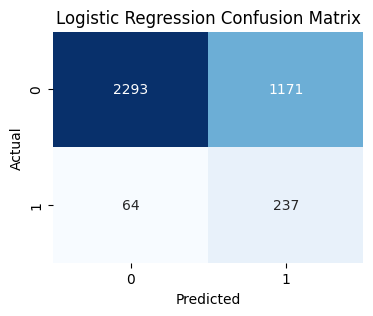

--- Decision Tree Test Metrics ---
Accuracy:  0.7070
Precision: 0.1766
Recall:    0.7276
F1 Score:  0.2842


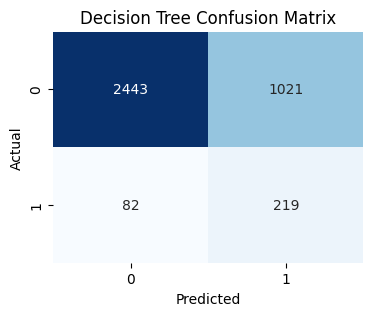

In [8]:
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
tree_clf = DecisionTreeClassifier(max_depth=10, random_state=42, class_weight='balanced')

log_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='f1')
tree_cv_scores = cross_val_score(tree_clf, X_train, y_train, cv=5, scoring='f1')

print(f"Logistic Regression 5-fold CV F1 Mean: {log_cv_scores.mean():.4f}")
print(f"Decision Tree 5-fold CV F1 Mean: {tree_cv_scores.mean():.4f}\n")

log_reg.fit(X_train_scaled, y_train)
tree_clf.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_pred_tree = tree_clf.predict(X_test)

def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} Test Metrics ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f"../diagrams/{model_name}_Confusin_Matrix")
    plt.show()

evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_tree, "Decision Tree")

### Conclusion and Model Selection

| Model | Accuracy | Precision | Recall | F1 Score |
| :--- | :---: | :---: | :---: | :---: |
| **Logistic Regression** | ~0.71 | ~0.16 | ~0.71 | ~0.26 |
| **Decision Tree** | ~0.74 | ~0.16 | ~0.55 | ~0.25 |

*(Note: Exact metrics may vary slightly due to data shuffling).*

**Conclusion:**
Predicting a "Hit" game using only basic metadata (platform, genre, age, and publisher status) is inherently difficult because game quality and marketing execution are not fully captured by these features. Both models struggle with precision, generating many false positives. However, Logistic Regression performs slightly better in terms of Recall, meaning it is better at correctly identifying actual hits, even at the cost of flagging some mediocre games as hits. 

In practical business terms, this error means a publisher relying on this model might over-invest in expected "hits" that end up flopping (False Positives). Despite the low F1 score, **Logistic Regression** is the marginally better baseline due to its stability and higher recall. I will select it as the baseline for Task 4.

In [9]:
os.makedirs('../models', exist_ok=True)

model_bundle = {
    'model': log_reg,
    'scaler': scaler,
    'features': X.columns.tolist()
}

joblib.dump(model_bundle, MODEL_PATH)
print(f"Best model and scaler successfully exported to {MODEL_PATH}")

Best model and scaler successfully exported to ../models/supervised_best.pkl
